# ESRI Land Cover

* **Products used:** 
[io_lulc_annual_v02](http://localhost:81/products/io_lulc_annual_v02)

Notebook modified from https://github.com/opendatacube/cube-in-a-box/blob/main/notebooks/ESRI_Land_Cover.ipynb (based on [io-lulc](https://planetarycomputer.microsoft.com/dataset/io-lulc) (deprecated) and updated for [https://planetarycomputer.microsoft.com/dataset/io-lulc-annual-v02](io-lulc-annual-v02)).

## Background

This dataset, produced by [Impact Observatory](http://impactobservatory.com/), Microsoft, and Esri, displays a global map of land use and land cover (LULC) derived from ESA Sentinel-2 imagery at 10 meter resolution for the years 2017 - 2023. Each map is a composite of LULC predictions for 9 classes throughout the year in order to generate a representative snapshot of each year. This dataset was generated by Impact Observatory, which used billions of human-labeled pixels (curated by the National Geographic Society) to train a deep learning model for land classification. Each global map was produced by applying this model to the Sentinel-2 annual scene collections from the Mircosoft Planetary Computer. Each of the maps has an assessed average accuracy of over 75%.

These maps have been improved from Impact Observatory’s [previous release](https://planetarycomputer.microsoft.com/dataset/io-lulc-9-class) and provide a relative reduction in the amount of anomalous change between classes, particularly between “Bare” and any of the vegetative classes “Trees,” “Crops,” “Flooded Vegetation,” and “Rangeland”. This updated time series of annual global maps is also re-aligned to match the ESA UTM tiling grid for Sentinel-2 imagery.

**Product details:**
* Product name in the datacube: `"io_lulc_annual_v02"`
* `Land Cover` product
* Spatial resolution: 10 m
* Date-range (yearly dataset): 1984 to 2023
* Universal Transverse Mercator (UTM) map projection. World Geodetic System (WGS) 84 datum
* Stored in Cloud-Optimised GeoTIFF Format (COG)

## Description

This notebook will run through loading in io_lulc_annual_v02 Product images.
Topics covered include:

* Using the native `dc.load()` function to load in Land Cover data
* Using local function to plot Land Cover

## Getting started

To run this analysis, run all the cells in the notebook, starting with the "Load packages" cell.

### Load packages

In [1]:
import sys
sys.path.insert(1, '../utils/')

In [2]:
# reload module before executing code
%load_ext autoreload
%autoreload 2

import datacube
from utils.deafrica_plotting import display_map

from planetary_computer import sign_url  # needed to access planetary-computer collection

### Create a local function

In [3]:
# Function(s)

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

def plot_da_categories(da, vcls, title=None, cb=True, **kwargs):
    """
    Plot categorical data with optional colorbar and title.

    Parameters:
    ----------
    da : xarray.DataArray
        The data array containing the categorical data to be plotted.
    vcls : list of tuples
        A list of tuples where each tuple contains (value, color, label).
        - value: The categorical value.
        - color: The RGB color as a tuple of integers (0-255).
        - label: The label for the category.
    title : str, optional
        The title of the plot. If None, the time value of the data array will be used as the title.
    cb : bool, optional
        Whether to display the colorbar. Default is True.
    **kwargs : dict
        Additional keyword arguments to pass to plt.subplots.
    """

    ticks, colors, labels = zip(*vcls)
    cmap = mcolors.ListedColormap([np.array(color) / 255 for color in colors])
    value_to_index = {value: index for index, value in enumerate(ticks)}
    mapped_data = np.vectorize(value_to_index.get)(da)
    norm = mcolors.BoundaryNorm(boundaries=np.arange(-0.5, len(ticks), 1), ncolors=cmap.N, clip=True)

    # Plot the data using matplotlib's pcolormesh
    fig, ax = plt.subplots(**kwargs)
    im = ax.pcolormesh(da.x, da.y, mapped_data, cmap=cmap, norm=norm)
    cbar = fig.colorbar(im, ax=ax, ticks=np.arange(len(ticks)))
    cbar.ax.set_yticklabels(labels)

    if not cb:
        # Hide the colorbar completely
        cbar.ax.set_visible(False)

    if title is None:
        plt.title(da.time.values)
    else:
        plt.title(title)
    plt.gca().set_aspect('equal')
    plt.show()

### Connect to the datacube

In [4]:
dc = datacube.Datacube(app='ESRI_Land_Cover')

## Describe product measurements

In [5]:
dc.list_measurements().loc['io_lulc_annual_v02']

,name,dtype,units,nodata,aliases,flags_definition
measurement,,,,,,
data,data,uint8,1,0,[classification],"{'data': {'bits': [0, 1, 2, 3, 4, 5, 6, 7], 'v..."


## Load ESRI Land Cover data from the datacube

As this product contains only a single integer band for a limited number of times, and consequently is way lighter than other available products, we will process it the light way, meaning without Daskerization (as in other products notebooks).

In [6]:
# Configure a bounding box and visualize it
lat, lon = 22.821, 28.518
buffer = 0.1

display_map(x=(lon - buffer, lon + buffer), y=(lat + buffer, lat - buffer))

In [7]:
# Create a query object (we don't need to define time range and measurements as it is a
# single time and single band product) and use it to load the data

query = {
    'product': 'io_lulc_annual_v02',
    'x': (lon - buffer, lon + buffer),
    'y': (lat + buffer, lat - buffer),
    'output_crs': 'epsg:6933',
    'resolution':30,
    'patch_url': sign_url,
}

ds = dc.load(**query)
print(ds)

<xarray.Dataset>
Dimensions:      (time: 7, x: 644, y: 787)
Coordinates:
  * time         (time) datetime64[ns] 2017-07-02T12:00:00 ... 2023-07-02T12:...
  * y            (y) float64 2.849e+06 2.849e+06 ... 2.825e+06 2.825e+06
  * x            (x) float64 2.742e+06 2.742e+06 ... 2.761e+06 2.761e+06
    spatial_ref  int32 6933
Data variables:
    data         (time, y, x) uint8 8 8 8 8 8 8 8 8 8 8 ... 5 5 5 5 5 5 5 8 8 8
Attributes:
    crs:           EPSG:6933
    grid_mapping:  spatial_ref


## Plot ESRI  Land Cover

To do so you need to first define the style of each Land Cover category

In [8]:
# Define Value, Color and Label triplets
vcls = [
    (0, (0, 0, 0), 'no data'),
    (1, (65, 155, 223), 'water'),
    (2, (57, 125, 73), 'trees'),
    (4, (122, 135, 198), 'flooded vegetation'),
    (5, (228, 150, 53), 'crops'),
    (7, (196, 40, 27), 'built area'),
    (8, (165, 155, 143), 'bare ground'),
    (9, (168, 235, 255), 'snow/ice'),
    (10, (97, 97, 97), 'clouds'),
    (11, (227, 226, 195), 'rangeland')
]

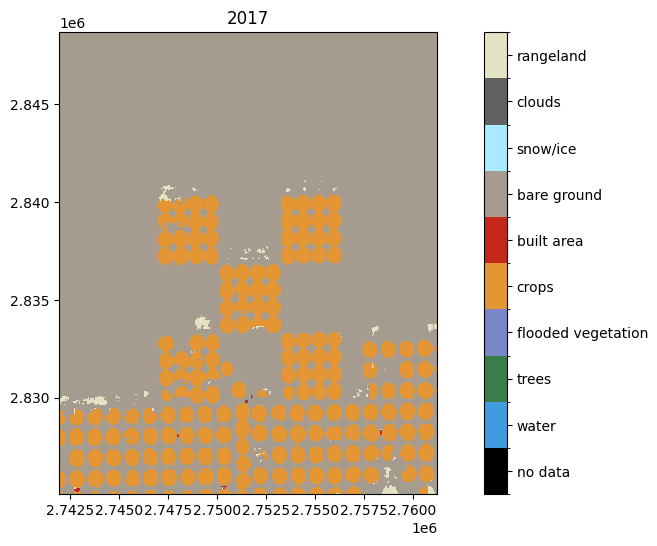

In [9]:
# Plot the first time

da = ds["data"].isel(time=0)
plot_da_categories(da, vcls, title= da.time.values.astype('datetime64[Y]').astype(int) + 1970,
                   cb=True, figsize=(12, 6))

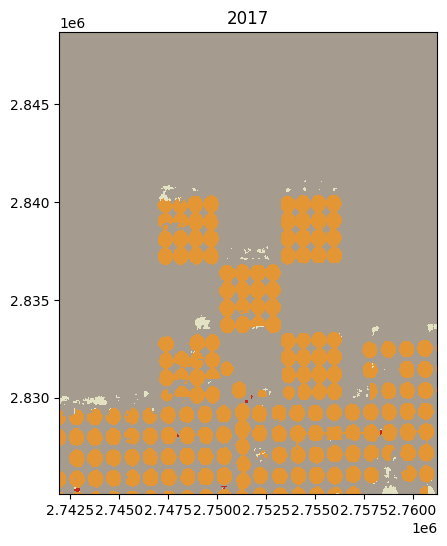

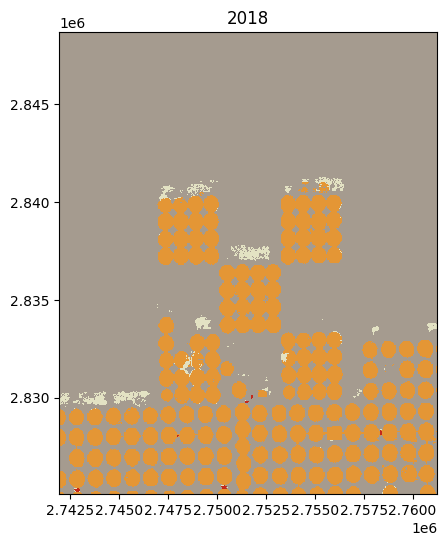

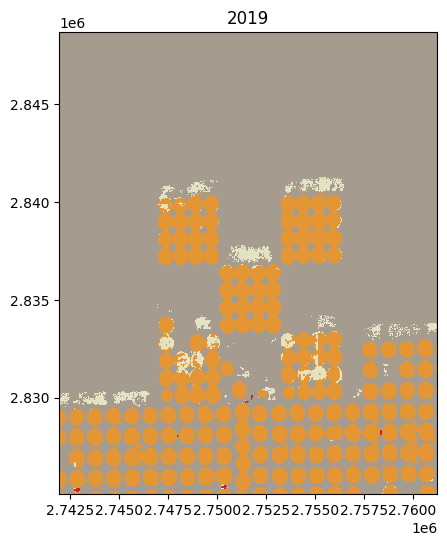

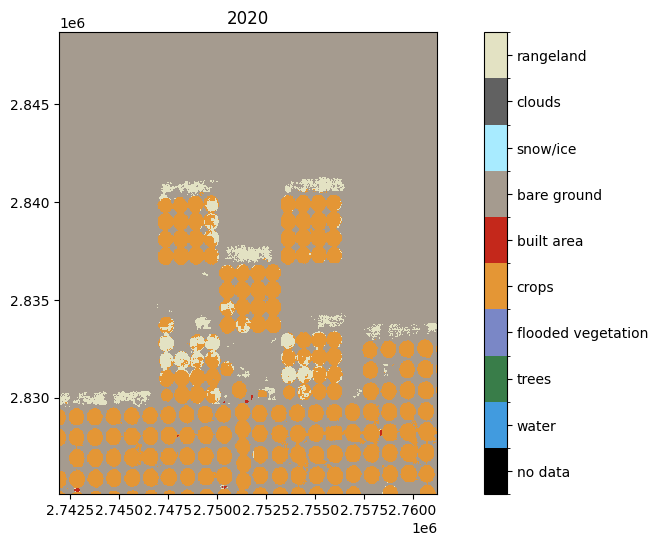

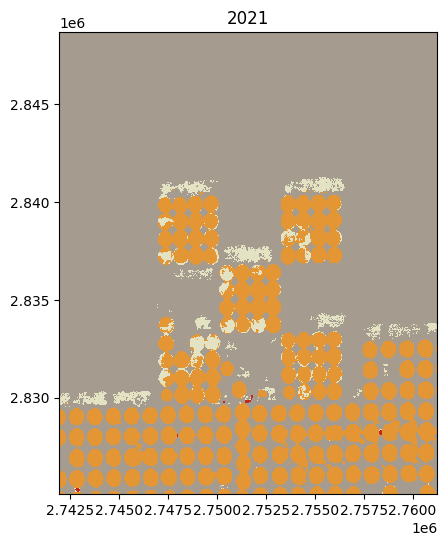

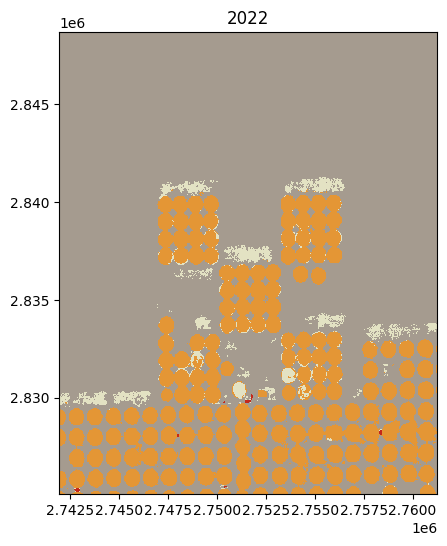

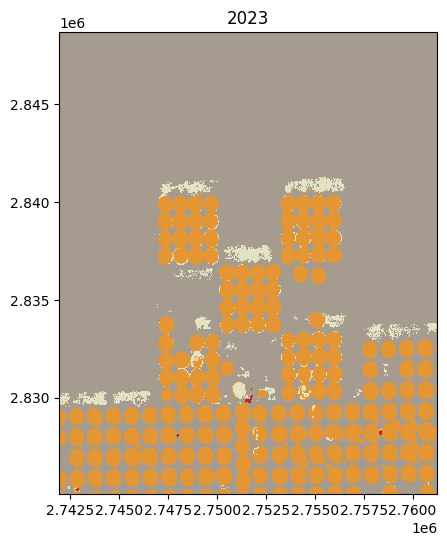

In [10]:
# Plot all time, displyaing a colorbar only midway

for idx in range(len(ds.time)):
    da = ds["data"].isel(time=idx)
    cb = idx == np.floor(len(ds.time) / 2)  # display colorbar midway
    plot_da_categories(da, vcls, title= da.time.values.astype('datetime64[Y]').astype(int) + 1970,
                       cb=cb, figsize=(12, 6))

***

## Additional information

**License:** The code in this notebook is slighly modified from https://github.com/digitalearthafrica/deafrica-sandbox-notebooks and licensed under the [Apache License, Version 2.0](https://www.apache.org/licenses/LICENSE-2.0).

**Compatible datacube version:**

In [11]:
print(datacube.__version__)

1.9.0


In [12]:
from datetime import datetime
datetime.today().strftime('%Y-%m-%d')

'2025-01-14'